# Real ChIP-seq TF Motif Detection with a 1D CNN: CTCF in K562 (PyTorch)

This notebook is a **step-by-step tutorial** for learning **transcription factor motif detection** from a **real ChIP-seq dataset** using a **1D CNN**.

## Biological question
Can a CNN learn the **CTCF binding motif** from real ChIP-seq peaks?

## Dataset choice
This notebook uses a real **ENCODE** dataset:

- **TF:** CTCF
- **Cell line:** K562
- **Experiment accession:** `ENCSR000EGM`
- **Peak file:** `ENCFF396BZQ`
- **Peak type:** optimal IDR thresholded peaks
- **Assembly:** GRCh38


## Important note
This notebook uses the internet to download:
1. the ENCODE peak file
2. the UCSC hg38 reference genome FASTA

If you are running offline, download those files manually first and put them in the expected paths.

In [1]:
# If needed, uncomment and run:
# !pip install pyfaidx pandas scikit-learn logomaker

In [4]:
import gzip
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from pyfaidx import Fasta

try:
    from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

try:
    import logomaker
    LOGOMAKER_AVAILABLE = True
except ImportError:
    LOGOMAKER_AVAILABLE = False

print("PyTorch version:", torch.__version__)
print("scikit-learn available:", SKLEARN_AVAILABLE)
print("logomaker available:", LOGOMAKER_AVAILABLE)

PyTorch version: 2.10.0
scikit-learn available: True
logomaker available: True


## 1. Reproducibility and device setup

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Define the real dataset resources

We use:
- the ENCODE optimal IDR thresholded peak set for **CTCF ChIP-seq in K562**
- the UCSC **hg38** reference genome FASTA

### Why peak summits?
A narrowPeak file includes a summit offset.
The summit is often close to the strongest binding signal.

For motif learning, it is common to extract a fixed window around the summit.

In [6]:
DATA_DIR = Path("./ctcf_chipseq_real")
DATA_DIR.mkdir(exist_ok=True)

PEAKS_URL = "https://www.encodeproject.org/files/ENCFF396BZQ/@@download/ENCFF396BZQ.bed.gz"
PEAKS_PATH = DATA_DIR / "ENCFF396BZQ.bed.gz"

FASTA_URL = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz"
FASTA_PATH = DATA_DIR / "hg38.fa.gz"

WINDOW_SIZE = 201   # odd number keeps a clear center base
HALF_WINDOW = WINDOW_SIZE // 2

print("Data directory:", DATA_DIR.resolve())
print("Peaks path:", PEAKS_PATH)
print("FASTA path:", FASTA_PATH)

Data directory: /Users/josoga2/Documents/wale_docs/phd/HB/py/basic_ml/08_CNN/ctcf_chipseq_real
Peaks path: ctcf_chipseq_real/ENCFF396BZQ.bed.gz
FASTA path: ctcf_chipseq_real/hg38.fa.gz


## 3. Download the files

If the files are already present, the notebook will skip downloading.

In [7]:
import urllib.request

def download_file(url, out_path):
    out_path = Path(out_path)
    if out_path.exists():
        print(f"Already exists: {out_path.name}")
        return
    print(f"Downloading {url} -> {out_path}")
    urllib.request.urlretrieve(url, out_path)
    print("Done.")

download_file(PEAKS_URL, PEAKS_PATH)
download_file(FASTA_URL, FASTA_PATH)

Done.
Done.


## 4. Read the narrowPeak file

ENCODE narrowPeak is essentially a BED-like format with 10 columns:

1. chromosome
2. start
3. end
4. name
5. score
6. strand
7. signalValue
8. pValue
9. qValue
10. peak summit offset from start

We care especially about:
- chromosome
- start
- end
- summit offset

In [8]:
peak_columns = [
    "chrom", "start", "end", "name", "score", "strand",
    "signalValue", "pValue", "qValue", "peak"
]

peaks_df = pd.read_csv(
    PEAKS_PATH,
    sep="\t",
    header=None,
    names=peak_columns,
    compression="gzip"
)

print("Peak table shape:", peaks_df.shape)
peaks_df.head()

Peak table shape: (57244, 10)


,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak
0,chr22,19648353,19648593,.,616,.,6.43590,-1.0,0.00428,120
1,chr2,86624105,86624345,.,609,.,6.46273,-1.0,-0.00067,120
2,chr19,42919707,42919947,.,1000,.,6.46847,-1.0,-0.00018,120
3,chr1,35641559,35641799,.,1000,.,6.52180,-1.0,0.00080,120
4,chrX,11759335,11759575,.,548,.,6.52258,-1.0,0.00235,120


## 5. Basic filtering

We will keep only standard chromosomes:
- chr1 to chr22
- chrX
- chrY

This avoids complications from alternative contigs and unusual sequence records.

In [9]:
standard_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

peaks_df = peaks_df[peaks_df["chrom"].isin(standard_chroms)].copy()
peaks_df = peaks_df.reset_index(drop=True)

print("Filtered peak count:", len(peaks_df))
peaks_df["chrom"].value_counts().head()

Filtered peak count: 57202


chrom
chr1    6085
chr2    4260
chr6    3557
chr3    3437
chr7    3220
Name: count, dtype: int64

## 6. Open the reference genome

We use `pyfaidx`, which lets us access chromosome sequences efficiently without loading the whole genome into memory.

In [19]:
genome = Fasta('./ctcf_chipseq_real/hg38.fa', as_raw=True, sequence_always_upper=True)
print("Example chromosome names:", list(genome.keys())[:5])
print("chr1 length:", len(genome["chr1"]))

Example chromosome names: ['chr1', 'chr10', 'chr11', 'chr11_KI270721v1_random', 'chr12']
chr1 length: 248956422


## 7. Build fixed windows around peak summits

For each peak:
- summit genomic position = `start + peak`
- sequence window = `[summit - half_window, summit + half_window]`

We also:
- drop windows that fall off chromosome edges
- drop sequences containing ambiguous bases like `N`

This makes the training data cleaner.

In [20]:
def extract_summit_centered_sequence(row, genome, window_size=201):
    half = window_size // 2
    summit = int(row["start"]) + int(row["peak"])

    start = summit - half
    end = summit + half + 1

    chrom = row["chrom"]
    chrom_len = len(genome[chrom])

    if start < 0 or end > chrom_len:
        return None

    seq = genome[chrom][start:end]
    if len(seq) != window_size:
        return None
    if "N" in seq:
        return None

    return seq

positive_sequences = []
kept_rows = []

for _, row in peaks_df.iterrows():
    seq = extract_summit_centered_sequence(row, genome, window_size=WINDOW_SIZE)
    if seq is not None:
        positive_sequences.append(seq)
        kept_rows.append(row)

peaks_clean_df = pd.DataFrame(kept_rows).reset_index(drop=True)

print("Usable positive sequences:", len(positive_sequences))
print("Example positive sequence:", positive_sequences[0][:60] + "...")

Usable positive sequences: 57202
Example positive sequence: AGGGATAAAACAATATCTGAAGAAATAATGGCTGAAATTTTTGATAAAAAACATATATGT...


## 8. Create negative sequences by shuffling positives

We want the model to focus on **motif structure**, not just simple base composition.

A convenient teaching choice is:
- take each positive sequence
- shuffle its nucleotides
- use that as a negative

This preserves:
- sequence length
- overall nucleotide composition

But it destroys the real motif arrangement.

### Important note
For more advanced analyses, stronger negatives are often used, such as:
- dinucleotide shuffles
- matched genomic background
- chromatin-matched negatives

In [21]:
def shuffle_sequence(seq):
    chars = list(seq)
    random.shuffle(chars)
    return "".join(chars)

negative_sequences = [shuffle_sequence(seq) for seq in positive_sequences]

print("Positive example:", positive_sequences[0])
print("Negative example:", negative_sequences[0])

Positive example: AGGGATAAAACAATATCTGAAGAAATAATGGCTGAAATTTTTGATAAAAAACATATATGTATAGTTCAAGAAGCTCAAGAAACTCCAAGTGGAGTAAACTGAAAGACATCTACACCTAGATGCATCATAATCAAACTGTCAAAAACCAAAGACAAAGCGAGCATCTCAGAGCAGCAGGACAGAAGCCACTTGTCACACACA
Negative example: CAAAAGTGTTTGAAGAATGGATGACAATTCTCAAAGTATACACAGACCCAAAACAACCCAATGGCGCAAGCCTCTAGAATCGCAAGGAAAGTAGAGAGCCCAGATCCTCAATAAATAATGAAACCATATGTTGTACTAATGCTAACAAACGAAAGGAAAGAGTGACTGAGCAATCAAAAATTAAATAACCGACATAATATT


## 9. Assemble labels

We define:
- `1` = real ChIP-seq peak-centered sequence
- `0` = shuffled negative

In [22]:
all_sequences = positive_sequences + negative_sequences
all_labels = [1] * len(positive_sequences) + [0] * len(negative_sequences)

print("Total sequences:", len(all_sequences))
print("Label distribution:", Counter(all_labels))

Total sequences: 114404
Label distribution: Counter({1: 57202, 0: 57202})


## 10. One-hot encode DNA

A, C, G, T become 4 channels.

For a sequence of length `L`, the one-hot shape is:
- `[4, L]`

That matches what `Conv1d` expects:
- `[batch, channels, length]`

In [23]:
NUCLEOTIDES = ["A", "C", "G", "T"]
BASE_TO_INDEX = {base: i for i, base in enumerate(NUCLEOTIDES)}

def one_hot_encode_dna(seq):
    arr = np.zeros((4, len(seq)), dtype=np.float32)
    for pos, base in enumerate(seq):
        arr[BASE_TO_INDEX[base], pos] = 1.0
    return arr

example = one_hot_encode_dna(all_sequences[0])
print("Example one-hot shape:", example.shape)
print(example[:, :12])

Example one-hot shape: (4, 201)
[[1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


## 11. Wrap data in a PyTorch Dataset

In [24]:
class ChipSeqMotifDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]

        x = torch.tensor(one_hot_encode_dna(seq), dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.float32)

        return {
            "sequence": seq,
            "x": x,
            "y": y
        }

dataset = ChipSeqMotifDataset(all_sequences, all_labels)
print("Dataset size:", len(dataset))

Dataset size: 114404


## 12. Inspect a few examples

We print a few sequences and labels so learners can connect:
- raw DNA
- label
- expected biology

In [25]:
for i in range(3):
    sample = dataset[i]
    print(f"Sample {i}")
    print("Label:", int(sample["y"].item()))
    print("Sequence:", sample["sequence"][:80] + "...")
    print("-" * 80)

Sample 0
Label: 1
Sequence: AGGGATAAAACAATATCTGAAGAAATAATGGCTGAAATTTTTGATAAAAAACATATATGTATAGTTCAAGAAGCTCAAGA...
--------------------------------------------------------------------------------
Sample 1
Label: 1
Sequence: ACTTTGTGTATTTTTTGTAAAAATAGAGCAGTTAATTATTCTCTTAAAATCGGTGAAAATAGAAATGTACGTTTTTTGAT...
--------------------------------------------------------------------------------
Sample 2
Label: 1
Sequence: GTTACAGCTCCTTCACCTTCCAGCCCCGTGAGACCCAGTCTTTGTGGCTGTACGTTCACTGTTCTCCCTCTTTCACAGTC...
--------------------------------------------------------------------------------


## 13. Train / validation / test split

In [26]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 80082
Val size: 17160
Test size: 17162


## 14. DataLoaders

For sequence CNNs, the batch input shape is:
- `[B, 4, L]`

where:
- `B` = batch size
- `4` = A/C/G/T channels
- `L` = sequence length

In [27]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Input tensor shape:", batch["x"].shape)
print("Label tensor shape:", batch["y"].shape)

Input tensor shape: torch.Size([128, 4, 201])
Label tensor shape: torch.Size([128])


## 15. Why a 1D CNN makes sense here

A motif is a **local sequence pattern**.


## 16. Build the CNN

We will use:
- a first convolution layer with motif-like filters
- ReLU
- max pooling
- a second convolution layer
- global max pooling
- fully connected classifier

### Why set the first kernel size to 19?
The classic CTCF motif is around this scale, so using a kernel size near the motif length is a sensible teaching choice.

In [28]:
class CTCFMotifCNN(nn.Module):
    def __init__(self, num_filters1=64, num_filters2=128, kernel_size1=19, kernel_size2=9, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=4,
            out_channels=num_filters1,
            kernel_size=kernel_size1,
            padding=kernel_size1 // 2
        )

        self.conv2 = nn.Conv1d(
            in_channels=num_filters1,
            out_channels=num_filters2,
            kernel_size=kernel_size2,
            padding=kernel_size2 // 2
        )

        self.pool = nn.MaxPool1d(kernel_size=2)
        self.global_pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(num_filters2, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x: [B, 4, L]

        x = self.conv1(x)
        x = F.relu(x)

        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        logits = self.fc2(x).squeeze(-1)
        return logits

model = CTCFMotifCNN().to(device)
model

CTCFMotifCNN(
  (conv1): Conv1d(4, 64, kernel_size=(19,), stride=(1,), padding=(9,))
  (conv2): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

## 17. Inspect tensor shapes


In [29]:
x = batch["x"][:4].to(device)

with torch.no_grad():
    print("Input:", x.shape)

    x1 = model.conv1(x)
    print("After conv1:", x1.shape)

    x1 = F.relu(x1)
    x1 = model.pool(x1)
    print("After pool:", x1.shape)

    x2 = model.conv2(x1)
    print("After conv2:", x2.shape)

    x2 = F.relu(x2)
    x3 = model.global_pool(x2)
    print("After global pool:", x3.shape)

    x4 = x3.squeeze(-1)
    print("After squeeze:", x4.shape)

    x5 = model.fc1(x4)
    print("After fc1:", x5.shape)

    logits = model.fc2(F.relu(x5)).squeeze(-1)
    print("Final logits:", logits.shape)

Input: torch.Size([4, 4, 201])
After conv1: torch.Size([4, 64, 201])
After pool: torch.Size([4, 64, 100])
After conv2: torch.Size([4, 128, 100])
After global pool: torch.Size([4, 128, 1])
After squeeze: torch.Size([4, 128])
After fc1: torch.Size([4, 64])
Final logits: torch.Size([4])


## 18. Define loss and optimizer

This is a binary classification task, so we use:
- `BCEWithLogitsLoss`

The model outputs raw scores called **logits**.
Later, we apply `sigmoid` to convert them into probabilities.

In [30]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 19. Define training and evaluation functions

We will track:
- loss
- accuracy


In [31]:
def binary_accuracy_from_logits(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += binary_accuracy_from_logits(logits.detach(), y)
        total_batches += 1

    return {
        "loss": running_loss / total_batches,
        "acc": running_acc / total_batches
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    all_logits = []
    all_labels = []

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item()
        running_acc += binary_accuracy_from_logits(logits, y)
        total_batches += 1

        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    metrics = {
        "loss": running_loss / total_batches,
        "acc": running_acc / total_batches,
        "logits": all_logits,
        "labels": all_labels
    }

    if SKLEARN_AVAILABLE:
        probs = torch.sigmoid(all_logits).numpy()
        labels_np = all_labels.numpy()

        metrics["auroc"] = roc_auc_score(labels_np, probs)
        metrics["auprc"] = average_precision_score(labels_np, probs)

    return metrics

## 20. Train the model

In [32]:
num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auroc": [],
    "val_auprc": [],
}

best_val_metric = -1
best_state = None

for epoch in range(1, num_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_acc"].append(val_metrics["acc"])

    if SKLEARN_AVAILABLE:
        history["val_auroc"].append(val_metrics["auroc"])
        history["val_auprc"].append(val_metrics["auprc"])
        selection_metric = val_metrics["auroc"]
    else:
        selection_metric = val_metrics["acc"]

    if selection_metric > best_val_metric:
        best_val_metric = selection_metric
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    msg = (
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Train acc: {train_metrics['acc']:.4f} | "
        f"Val acc: {val_metrics['acc']:.4f}"
    )
    if SKLEARN_AVAILABLE:
        msg += f" | Val AUROC: {val_metrics['auroc']:.4f} | Val AUPRC: {val_metrics['auprc']:.4f}"
    print(msg)

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model based on validation metric.")

Epoch 01 | Train loss: 0.2229 | Val loss: 0.1975 | Train acc: 0.8956 | Val acc: 0.9268 | Val AUROC: 0.9939 | Val AUPRC: 0.9947
Epoch 02 | Train loss: 0.0903 | Val loss: 0.0959 | Train acc: 0.9668 | Val acc: 0.9640 | Val AUROC: 0.9954 | Val AUPRC: 0.9959
Epoch 03 | Train loss: 0.0715 | Val loss: 0.0854 | Train acc: 0.9741 | Val acc: 0.9679 | Val AUROC: 0.9959 | Val AUPRC: 0.9964
Epoch 04 | Train loss: 0.0599 | Val loss: 0.0886 | Train acc: 0.9790 | Val acc: 0.9652 | Val AUROC: 0.9960 | Val AUPRC: 0.9964
Epoch 05 | Train loss: 0.0438 | Val loss: 0.0760 | Train acc: 0.9852 | Val acc: 0.9722 | Val AUROC: 0.9964 | Val AUPRC: 0.9967
Epoch 06 | Train loss: 0.0328 | Val loss: 0.0865 | Train acc: 0.9890 | Val acc: 0.9702 | Val AUROC: 0.9961 | Val AUPRC: 0.9965
Epoch 07 | Train loss: 0.0298 | Val loss: 0.0886 | Train acc: 0.9901 | Val acc: 0.9732 | Val AUROC: 0.9963 | Val AUPRC: 0.9967
Epoch 08 | Train loss: 0.0187 | Val loss: 0.1662 | Train acc: 0.9942 | Val acc: 0.9517 | Val AUROC: 0.9961 | Va

## 21. Plot learning curves

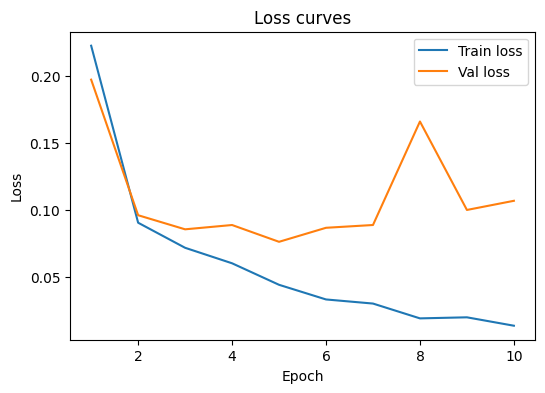

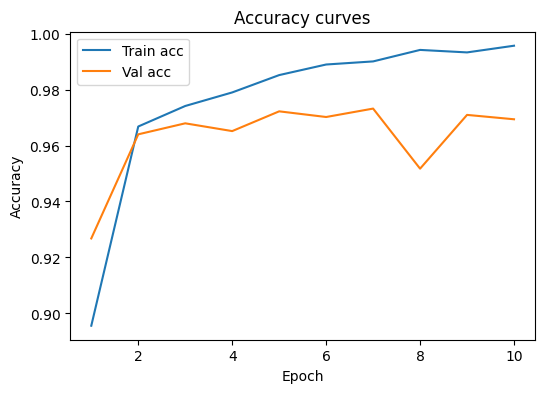

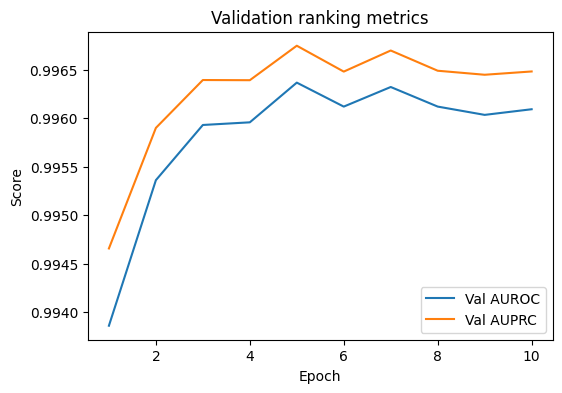

In [33]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train acc")
plt.plot(epochs, history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()

if SKLEARN_AVAILABLE:
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["val_auroc"], label="Val AUROC")
    plt.plot(epochs, history["val_auprc"], label="Val AUPRC")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Validation ranking metrics")
    plt.legend()
    plt.show()

## 22. Test-set evaluation

In [34]:
test_metrics = evaluate(model, test_loader, criterion, device)

print("Test loss:", round(test_metrics["loss"], 4))
print("Test accuracy:", round(test_metrics["acc"], 4))

if SKLEARN_AVAILABLE:
    print("Test AUROC:", round(test_metrics["auroc"], 4))
    print("Test AUPRC:", round(test_metrics["auprc"], 4))

Test loss: 0.0649
Test accuracy: 0.9752
Test AUROC: 0.9973
Test AUPRC: 0.9975


## 23. Inspect predictions on example sequences

This helps connect the model output back to actual DNA sequences.

In [35]:
@torch.no_grad()
def show_example_predictions(model, dataset, num_samples=6):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    for idx in indices:
        sample = dataset[idx]
        x = sample["x"].unsqueeze(0).to(device)

        logit = model(x).item()
        prob = torch.sigmoid(torch.tensor(logit)).item()
        pred = int(prob >= 0.5)
        true_label = int(sample["y"].item())

        print("Sequence:", sample["sequence"])
        print("True label:", true_label)
        print("Predicted probability:", round(prob, 4))
        print("Predicted label:", pred)
        print("-" * 100)

show_example_predictions(model, test_dataset, num_samples=6)

Sequence: GACAGCACTACTGCATGCCAGCCTGGGTGACAGAGCCAGACCCTGTCTCAGAAAAAAAAAAAAAAAAAAAAAAGTTAATAGAAGTATAGCACTCTGACCCCTAGTGGTTAAATTATGCAGAGAAAAATTCAGGACTTGTCCAAAGACAACAGGAGGTTGATTTATTTCACATTATGTTCCTGTATGATCTTTTTATCAGTT
True label: 1
Predicted probability: 1.0
Predicted label: 1
----------------------------------------------------------------------------------------------------
Sequence: GGAAAACAAGCTACTTAAACCTTGTCTTTTAGTAGTTTTAGGAGATACCATTTTTGGCACTTGTGTTATGTTACATTCTTGATACACAAGAGGTCAGTAGCGTTCTGCTTATAAGCATTTCTTGAAATCAAACATGGGCTAAACTTCATACTTTGGTTGTTTTTTTTTTTAATTGAAGCTACAGTGTTCACCATACTTTCA
True label: 1
Predicted probability: 0.9987
Predicted label: 1
----------------------------------------------------------------------------------------------------
Sequence: CTGTCATGAGCTTCGACATGTTGCCGTGAAATTGTGTTCCCGTAGTCACACCATAACTTGTAGATCCCGATTGAGCATGATGATATCGCCTGTTTAACAGGGGTACACATCGTTGCGAATGGATATGACTCTCAACGTACGTATAGACTGTTATGCCTATACTATAACCTTTCGTTGACCTCAGAAAAAGCCGCTCTTAAC
True label: 0
Predicted probability: 0.

## 24. Inspect first-layer filters

The first convolution layer has weight shape:

`[num_filters, 4, kernel_size]`

For DNA:
- 4 rows correspond to A/C/G/T
- columns correspond to positions within the motif window

This is why people often interpret first-layer filters as **motif detectors**.

In [36]:
first_layer_weights = model.conv1.weight.detach().cpu().numpy()

print("First-layer weight shape:", first_layer_weights.shape)
print("Meaning: [num_filters, 4, kernel_size]")

First-layer weight shape: (64, 4, 19)
Meaning: [num_filters, 4, kernel_size]


## 25. Visualize filters as heatmaps

A heatmap is the simplest way to inspect what each filter emphasizes.

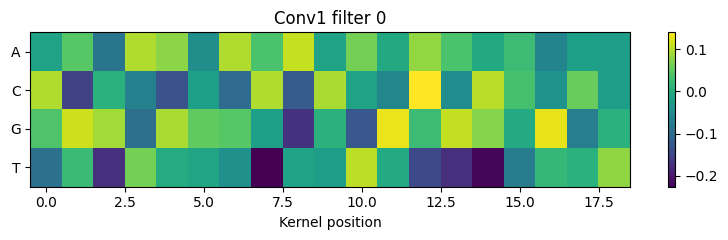

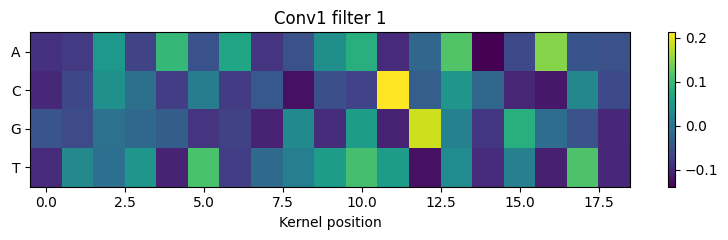

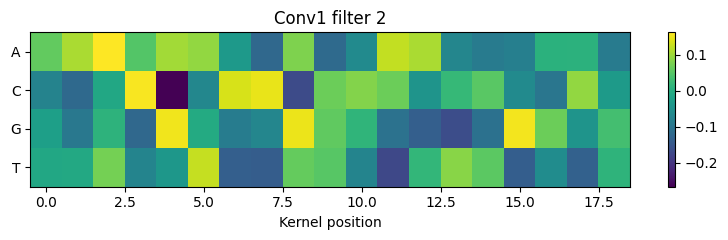

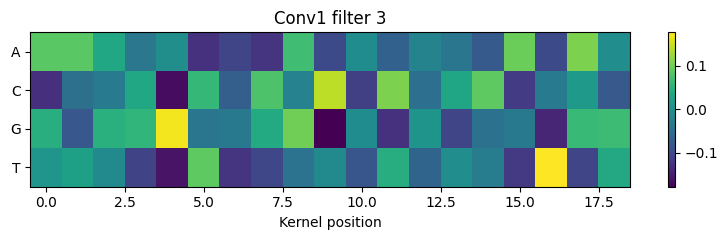

In [37]:
def plot_conv_filter(filter_weights, title=None):
    plt.figure(figsize=(8, 2.5))
    plt.imshow(filter_weights, aspect="auto")
    plt.yticks(range(4), NUCLEOTIDES)
    plt.xlabel("Kernel position")
    if title is not None:
        plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for i in range(min(4, first_layer_weights.shape[0])):
    plot_conv_filter(first_layer_weights[i], title=f"Conv1 filter {i}")

## 26. Build a simple consensus-like interpretation

A beginner-friendly trick:
- at each position in the filter
- pick the nucleotide with the largest weight

This gives a rough motif-like consensus.

This is only an approximation, but it helps build intuition.

In [38]:
def filter_to_consensus(filter_weights):
    consensus = ""
    for pos in range(filter_weights.shape[1]):
        best_idx = np.argmax(filter_weights[:, pos])
        consensus += NUCLEOTIDES[best_idx]
    return consensus

for i in range(min(10, first_layer_weights.shape[0])):
    print(f"Filter {i:02d}: {filter_to_consensus(first_layer_weights[i])}")

Filter 00: CGGAGGACACTGCGCCGCT
Filter 01: GTATATATGTTCGACGATA
Filter 02: AAACGTCCGCCAATTGGCG
Filter 03: AAGGGTGCGCACGCCATAG
Filter 04: GAACGTGGAACTTGAAGTT
Filter 05: TATTACTTACCGGACGTAA
Filter 06: GCACAGTTACCACCGATCG
Filter 07: GCCACTGCAGAAAGGTTGC
Filter 08: GAGTAGTACGTTCGTCTAG
Filter 09: CTTACATCCACATGGCGGC


## 27. Optional: convert filters into sequence logos

If `logomaker` is installed, we can visualize a filter more like a motif logo.

This is not a full biophysical PWM conversion, but it is a helpful teaching visualization.

<Figure size 1000x250 with 0 Axes>

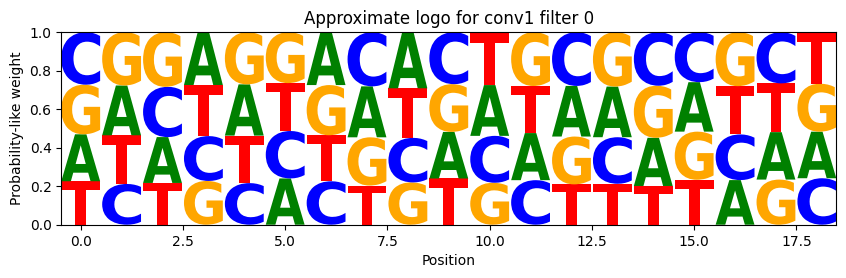

In [39]:
def normalize_filter_for_logo(filter_weights):
    # filter_weights shape: [4, K]
    arr = filter_weights.copy()

    # softmax over nucleotides at each position
    exp_arr = np.exp(arr - arr.max(axis=0, keepdims=True))
    probs = exp_arr / exp_arr.sum(axis=0, keepdims=True)

    df = pd.DataFrame({
        "A": probs[0],
        "C": probs[1],
        "G": probs[2],
        "T": probs[3],
    })
    return df

if LOGOMAKER_AVAILABLE:
    df_logo = normalize_filter_for_logo(first_layer_weights[0])
    plt.figure(figsize=(10, 2.5))
    logomaker.Logo(df_logo)
    plt.title("Approximate logo for conv1 filter 0")
    plt.xlabel("Position")
    plt.ylabel("Probability-like weight")
    plt.show()
else:
    print("Install logomaker to draw sequence-logo style filter plots.")